In [35]:
import pandas as pd
import seaborn as sns

In [76]:
data = pd.read_csv('transcoder_performance.csv')
alone_copy = data[data["type"] == "alone"].copy()


def map_row(row):
    alone_rate = alone_copy[alone_copy["segment"] == row["segment"]]["transcode_rate"].values[0]
    row["transcode_rate"] /= alone_rate
    return row

data = data.apply(map_row, axis=1)
data

,type,segment,transcode_rate
0,alone,1,1.000000
1,alone,2,1.000000
2,alone,3,1.000000
3,alone,4,1.000000
4,alone,5,1.000000
5,alone,6,1.000000
6,alone,7,1.000000
7,alone,8,1.000000
8,alone,9,1.000000
9,alone,10,1.000000


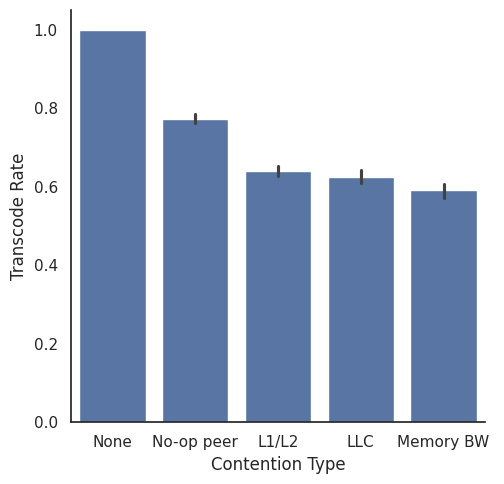

In [85]:
data_prepared = data.copy()
data_prepared["Transcode Rate"] = data_prepared["transcode_rate"]
data_prepared["type"] = data_prepared["type"].map({
    "alone": "None",
    "spin": "No-op peer",
    "l2": "L1/L2",
    "llc": "LLC",
    "mem_bw": "Memory BW",
})
plot = sns.catplot(data=data_prepared, x="type", y="Transcode Rate", kind="bar")
plot.set_xlabels("Contention Type")